In [65]:
import kagglehub

path = kagglehub.dataset_download("shubhamgoel27/dermnet")

print(path)

Using Colab cache for faster access to the 'dermnet' dataset.
/kaggle/input/dermnet


In [66]:
import os

print(os.listdir(path))

['test', 'train']


In [67]:
for root, dirs, files in os.walk(path):
    print(root)
    print(dirs[:5])
    print(files[:5])
    print("-"*50)

/kaggle/input/dermnet
['test', 'train']
[]
--------------------------------------------------
/kaggle/input/dermnet/test
['Light Diseases and Disorders of Pigmentation', 'Lupus and other Connective Tissue diseases', 'Acne and Rosacea Photos', 'Systemic Disease', 'Poison Ivy Photos and other Contact Dermatitis']
[]
--------------------------------------------------
/kaggle/input/dermnet/test/Light Diseases and Disorders of Pigmentation
[]
['polymorphous-light-eruption-33.jpg', 'milia-11.jpg', 'pseudo-porphyria-2.jpg', 'sun-damaged-skin-12.jpg', 'phototoxic-reactions-72.jpg']
--------------------------------------------------
/kaggle/input/dermnet/test/Lupus and other Connective Tissue diseases
[]
['crest-syndrome-12.jpg', 'rheumatoid-nodule-8.jpg', 'lupus-acute-24.jpg', 'morphea-96.jpg', 'rheumatoid-nodule-9.jpg']
--------------------------------------------------
/kaggle/input/dermnet/test/Acne and Rosacea Photos
[]
['acne-cystic-6.jpg', 'hidradenitis-suppurativa-43.jpg', 'acne-open-co

In [68]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import seaborn as sns

print("ok")

ok


In [69]:
train_dir = path + "/train"
test_dir = path + "/test"

print(train_dir)
print(test_dir)

/kaggle/input/dermnet/train
/kaggle/input/dermnet/test


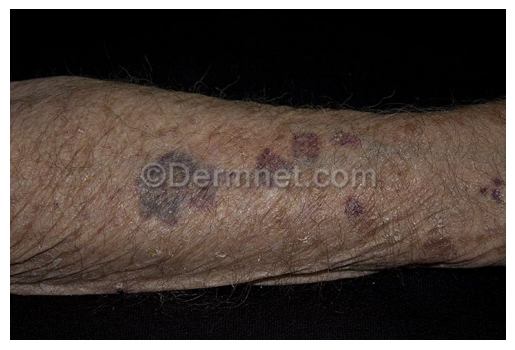

(720, 480)


In [70]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
import os

class_name = os.listdir(train_dir)[0]
img_path = os.path.join(train_dir, class_name, os.listdir(os.path.join(train_dir, class_name))[0])

img = image.load_img(img_path)
plt.imshow(img)
plt.axis("off")
plt.show()

print(img.size)

In [71]:
images, labels = next(iter(train_ds))

print(images[0].shape)

(224, 224, 3)


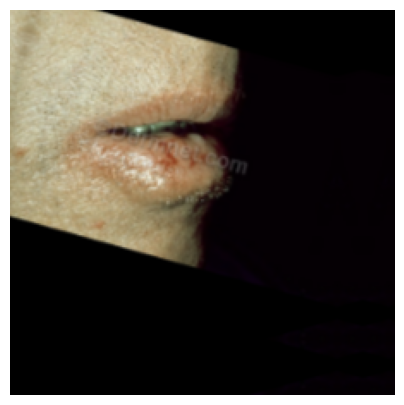

In [72]:
plt.figure(figsize=(5,5))
plt.imshow(images[0])
plt.axis("off")
plt.show()

In [73]:
train_datagen = ImageDataGenerator(

    rescale=1./255,

    rotation_range=20,

    width_shift_range=0.2,

    height_shift_range=0.2,

    zoom_range=0.2,

    horizontal_flip=True,

    validation_split=0.2
)

In [74]:
test_datagen = ImageDataGenerator(rescale=1./255)

In [75]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset='training',
    seed=123,
    image_size=(224, 224),
    pad_to_aspect_ratio=True,
    batch_size=32,
    label_mode='categorical'
)

Found 15557 files belonging to 23 classes.
Using 12446 files for training.


In [76]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset='validation',
    seed=123,
    image_size=(224, 224),
    pad_to_aspect_ratio=True,   # <-- prevents stretching
    batch_size=32,
    label_mode='categorical'
)

Found 15557 files belonging to 23 classes.
Using 3111 files for validation.


In [77]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(224, 224),
    pad_to_aspect_ratio=True,   # <-- prevents stretching
    batch_size=32,
    shuffle=False,
    label_mode='categorical'
)

Found 4002 files belonging to 23 classes.


In [78]:
import pathlib

def count_images(directory):
    return sum(len(files) for _, _, files in os.walk(directory))

print("Training Images :", int(train_ds.cardinality().numpy()) * 32)
print("Number of Classes :", len(train_ds.class_names))
print("Class names :", train_ds.class_names)

Training Images : 12448
Number of Classes : 23
Class names : ['Acne and Rosacea Photos', 'Actinic Keratosis Basal Cell Carcinoma and other Malignant Lesions', 'Atopic Dermatitis Photos', 'Bullous Disease Photos', 'Cellulitis Impetigo and other Bacterial Infections', 'Eczema Photos', 'Exanthems and Drug Eruptions', 'Hair Loss Photos Alopecia and other Hair Diseases', 'Herpes HPV and other STDs Photos', 'Light Diseases and Disorders of Pigmentation', 'Lupus and other Connective Tissue diseases', 'Melanoma Skin Cancer Nevi and Moles', 'Nail Fungus and other Nail Disease', 'Poison Ivy Photos and other Contact Dermatitis', 'Psoriasis pictures Lichen Planus and related diseases', 'Scabies Lyme Disease and other Infestations and Bites', 'Seborrheic Keratoses and other Benign Tumors', 'Systemic Disease', 'Tinea Ringworm Candidiasis and other Fungal Infections', 'Urticaria Hives', 'Vascular Tumors', 'Vasculitis Photos', 'Warts Molluscum and other Viral Infections']


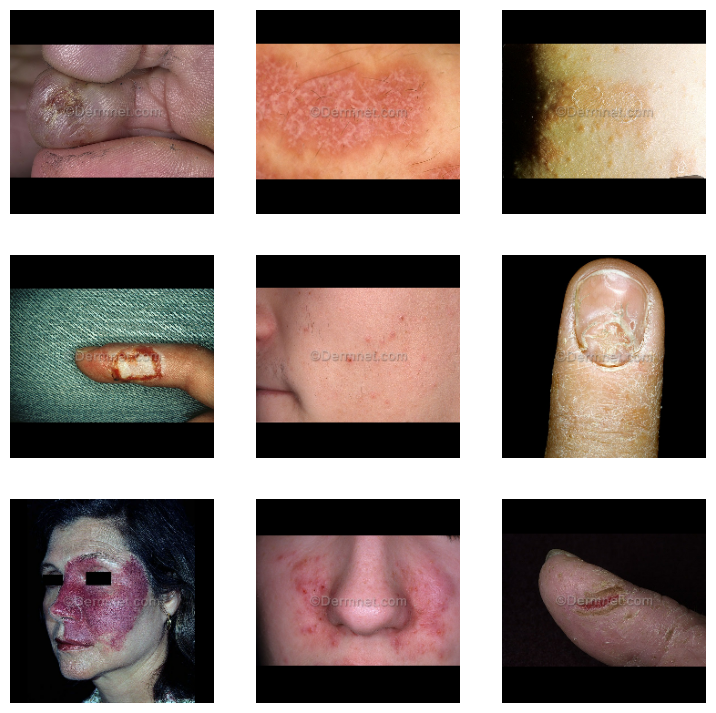

In [79]:
images, labels = next(iter(train_ds))

plt.figure(figsize=(9,9))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i].numpy() / 255.0)
    plt.axis("off")

plt.show()

In [80]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.055),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomTranslation(0.2, 0.2),
])

def prep_train(x, y):
    x = data_augmentation(x, training=True)
    x = normalization_layer(x)
    return x, y

def prep_eval(x, y):
    x = normalization_layer(x)
    return x, y

train_ds = train_ds.map(prep_train).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.map(prep_eval).prefetch(tf.data.AUTOTUNE)
test_ds_eval = test_ds.map(prep_eval).prefetch(tf.data.AUTOTUNE)

In [81]:
base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

base_model.trainable = False

In [82]:
num_classes = len(train_ds.class_names)

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
output = Dense(num_classes, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)

AttributeError: '_PrefetchDataset' object has no attribute 'class_names'